# 01 – Exploratory Data Analysis
PII Detection Project — Group 15


In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load raw datasets

In [12]:
kaggle = pd.read_csv('../pii_dataset.csv/pii_dataset.csv', dtype=str)
ai4p   = pd.read_csv('../PII43k.csv', dtype=str, on_bad_lines='skip', engine='python')
print(f'Kaggle rows:     {len(kaggle):,}')
print(f'ai4privacy rows: {len(ai4p):,}')

Kaggle rows:     4,434
ai4privacy rows: 42,759


## 2. Document length distributions

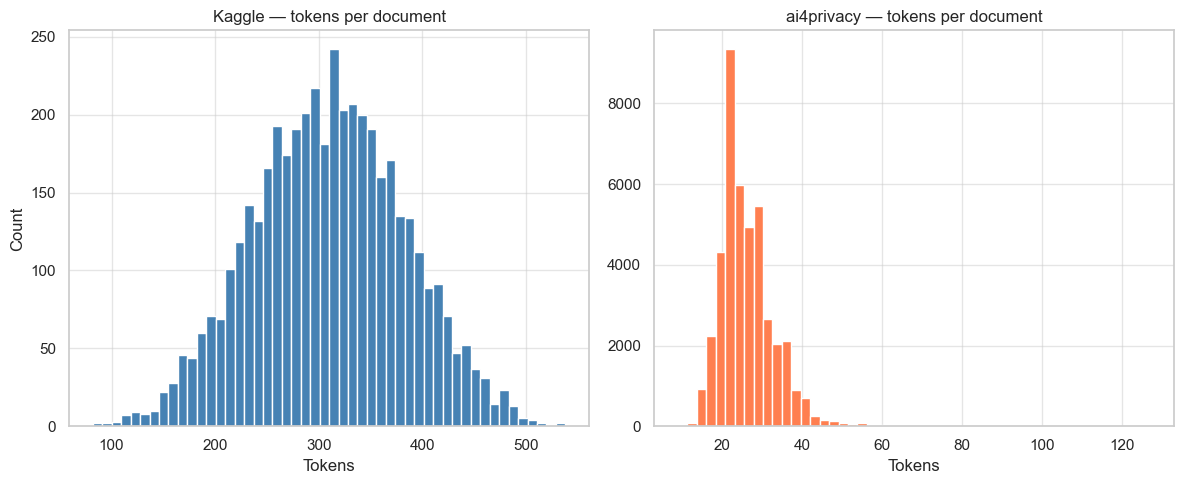

count    4434.0
mean      309.7
std        73.1
min        82.0
25%       258.0
50%       310.0
75%       360.0
max       538.0
Name: Kaggle, dtype: str
count    42759.0
mean        26.4
std          7.5
min          9.0
25%         22.0
50%         25.0
75%         30.0
max        127.0
Name: ai4privacy, dtype: str


In [13]:
kaggle['n_tokens'] = kaggle['tokens'].apply(lambda x: len(ast.literal_eval(x)))
ai4p['n_tokens']   = ai4p['Tokenised Filled Template'].apply(lambda x: len(ast.literal_eval(x)))

fig, axes = plt.subplots(1, 2)
axes[0].hist(kaggle['n_tokens'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Kaggle — tokens per document')
axes[0].set_xlabel('Tokens'); axes[0].set_ylabel('Count')

axes[1].hist(ai4p['n_tokens'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('ai4privacy — tokens per document')
axes[1].set_xlabel('Tokens')

plt.tight_layout()
plt.savefig('../outputs/results/eda_token_lengths.png', dpi=150)
plt.show()
print(kaggle['n_tokens'].describe().apply(lambda x: f'{x:.1f}').rename('Kaggle'))
print(ai4p['n_tokens'].describe().apply(lambda x: f'{x:.1f}').rename('ai4privacy'))

## 3. Entity type distributions (Kaggle raw labels)

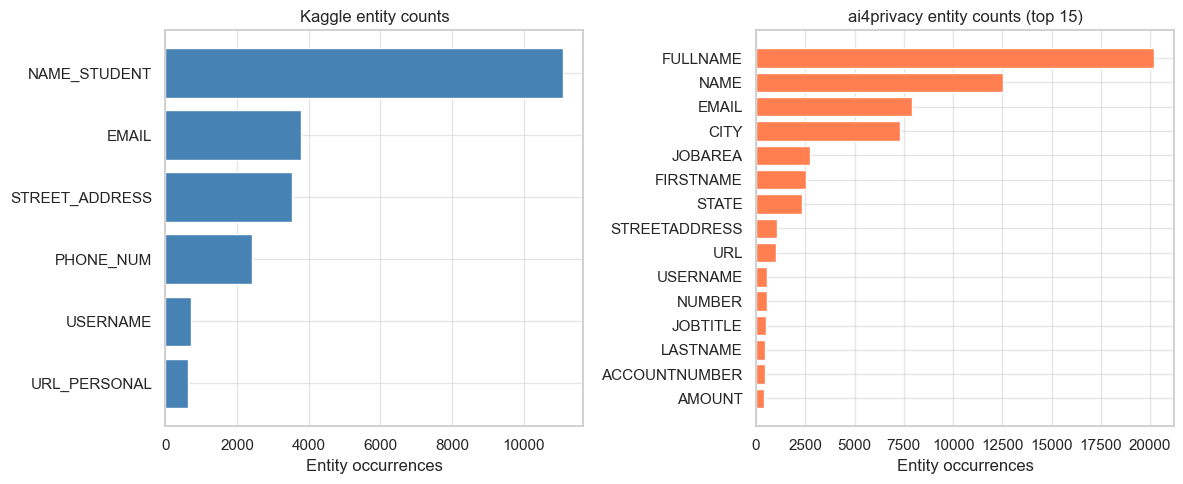

In [14]:
def count_entities(df, label_col):
    cnt = Counter()
    for row in df[label_col]:
        for lbl in ast.literal_eval(row):
            if lbl.startswith('B-'):
                cnt[lbl[2:]] += 1
    return cnt

k_cnt = count_entities(kaggle, 'labels')
a_cnt = count_entities(ai4p, 'Tokens')

fig, axes = plt.subplots(1, 2)
for ax, cnt, title, color in zip(axes,
    [k_cnt, a_cnt],
    ['Kaggle entity counts', 'ai4privacy entity counts (top 15)'],
    ['steelblue', 'coral']):
    top = cnt.most_common(15)
    labels, values = zip(*top) if top else ([], [])
    ax.barh(labels[::-1], values[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('Entity occurrences')

plt.tight_layout()
plt.savefig('../outputs/results/eda_entity_counts.png', dpi=150)
plt.show()

## 4. PII density — fraction of tokens that are PII

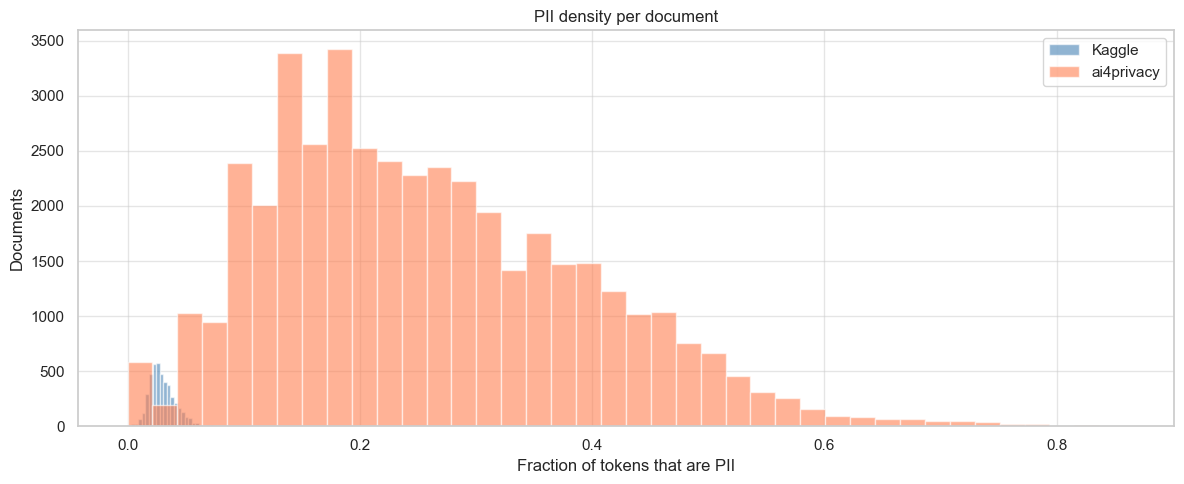

Kaggle mean density:     3.00%
ai4privacy mean density: 25.68%


In [15]:
def pii_density(df, label_col):
    densities = []
    for row in df[label_col]:
        lbls = ast.literal_eval(row)
        n_pii = sum(1 for l in lbls if l != 'O')
        densities.append(n_pii / len(lbls) if lbls else 0)
    return densities

k_dens = pii_density(kaggle, 'labels')
a_dens = pii_density(ai4p, 'Tokens')

fig, ax = plt.subplots()
ax.hist(k_dens, bins=40, alpha=0.6, label='Kaggle', color='steelblue')
ax.hist(a_dens, bins=40, alpha=0.6, label='ai4privacy', color='coral')
ax.set_xlabel('Fraction of tokens that are PII')
ax.set_ylabel('Documents')
ax.set_title('PII density per document')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/results/eda_pii_density.png', dpi=150)
plt.show()
print(f'Kaggle mean density:     {sum(k_dens)/len(k_dens)*100:.2f}%')
print(f'ai4privacy mean density: {sum(a_dens)/len(a_dens)*100:.2f}%')

## 5. Sample records

In [16]:
for i, row in kaggle.head(2).iterrows():
    tokens = ast.literal_eval(row['tokens'])
    labels = ast.literal_eval(row['labels'])
    pii_tokens = [(t, l) for t, l in zip(tokens, labels) if l != 'O']
    print(f'--- Kaggle record {i} ---')
    print(f'PII spans: {pii_tokens[:8]}\n')

--- Kaggle record 0 ---
PII spans: [('Aaliyah', 'B-NAME_STUDENT'), ('Popova,', 'I-NAME_STUDENT'), ('(95)', 'B-PHONE_NUM'), ('94215-7906', 'I-PHONE_NUM'), ('aaliyah.popova4783@aol.edu.', 'B-EMAIL'), ('97', 'B-STREET_ADDRESS'), ('Lincoln', 'I-STREET_ADDRESS'), ('Street.', 'I-STREET_ADDRESS')]

--- Kaggle record 1 ---
PII spans: [('Konstantin', 'B-NAME_STUDENT'), ('Becker,', 'I-NAME_STUDENT'), ('konstantin.becker@gmail.com', 'B-EMAIL'), ('0475', 'B-PHONE_NUM'), ('4429797.', 'I-PHONE_NUM'), ('826', 'B-STREET_ADDRESS'), ('Webster', 'I-STREET_ADDRESS'), ('Street.', 'I-STREET_ADDRESS')]

